1. Setup

1.1 Install Dependencies

In [1]:
%pip install tensorflow==2.4.1 tensorflow-gpu==2.4.1 opencv-python matplotlib

Using legacy 'setup.py install' for termcolor, since package 'wheel' is not installed.
Using legacy 'setup.py install' for wrapt, since package 'wheel' is not installed.
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
    Running setup.py install for wrapt: started
    Running setup.py install for wrapt: finished with status 'done'
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.13.2
    Uninstalling typing-extensions-4.13.2:
      Successfully uninstalled typing-extensions-4.13.2
    Running setup.py install for termcolor: started
    Running setup.py install for termcolor: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\zeynb\.gemini\antigravity\scratch\construction_safety_system\face_training_env\Scripts\python.exe -m pip install --upgrade pip' command.


1.2 Import Dependencies

In [3]:
# Import standard dependencies
import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt

In [4]:
# Import tensorflow dependencies - Functional API
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten # type: ignore
import tensorflow as tf

1.3 Set GPU Growth

In [5]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

1.4 Create Folder Structures

In [10]:
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [6]:
# Make the directories
os.makedirs(POS_PATH, exist_ok=True)
os.makedirs(NEG_PATH, exist_ok=True)
os.makedirs(ANC_PATH, exist_ok=True)

2. Collect Positives and Anchors

2.1 Untar Labelled Faces in the Wild Dataset

In [ ]:
# https://www.kaggle.com/datasets/jessicali9530/lfw-dataset

In [8]:
import os
import zipfile

# 1. Path to LFW.zip in your Downloads folder
DOWNLOADS_PATH = os.path.join(os.path.expanduser("~"), "Downloads")
ZIP_PATH = os.path.join(DOWNLOADS_PATH, "LFW.zip")

# Ensure data/negative exists
os.makedirs(NEG_PATH, exist_ok=True)

print("Extracting images directly from LFW.zip into", NEG_PATH, "...")

count = 0
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    for member in zip_ref.namelist():
        # Check if file is a JPEG image
        if member.lower().endswith(('.jpg', '.jpeg')):
            filename = os.path.basename(member)
            if filename:
                dest_path = os.path.join(NEG_PATH, filename)
                with open(dest_path, 'wb') as f:
                    f.write(zip_ref.read(member))
                count += 1

print(f" Done! Successfully extracted {count} negative images to: {NEG_PATH}")

Extracting images directly from LFW.zip into data\negative ...


KeyboardInterrupt: 

2.2 Collect Positive and Anchor Classes

In [6]:
# Import uuid library to generate unique image names
import uuid

In [6]:
os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))

'data\\anchor\\1ca87b60-b4e2-11f1-8c7a-cc47401e05e1.jpg'

In [6]:
import cv2
import os
import uuid

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # The crop region (what will be saved)
    cropped_frame = frame[120:120+250, 200:200+250, :]

    # Draw a rectangle on the full frame to show where the crop is
    display_frame = frame.copy()
    cv2.rectangle(display_frame, (200, 120), (450, 370), (0, 255, 0), 2)
    cv2.putText(display_frame, "Face region", (200, 115),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Show the FULL frame (not the tiny crop)
    cv2.imshow('Image Collection', display_frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('a'):
        imgname = os.path.join(ANC_PATH, f'{uuid.uuid1()}.jpg')
        cv2.imwrite(imgname, cropped_frame)
        print("Saved Anchor:", imgname)

    if key == ord('p'):
        imgname = os.path.join(POS_PATH, f'{uuid.uuid1()}.jpg')
        cv2.imwrite(imgname, cropped_frame)
        print("Saved Positive:", imgname)

    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Saved Anchor: data\anchor\0e793ba0-b38b-11f1-929a-cc47401e05e1.jpg
Saved Anchor: data\anchor\0eacbb2b-b38b-11f1-9557-cc47401e05e1.jpg
Saved Anchor: data\anchor\0eda90e8-b38b-11f1-af12-cc47401e05e1.jpg
Saved Anchor: data\anchor\0eff2495-b38b-11f1-834c-cc47401e05e1.jpg
Saved Anchor: data\anchor\0f301e5a-b38b-11f1-985e-cc47401e05e1.jpg
Saved Anchor: data\anchor\0f5492e3-b38b-11f1-a477-cc47401e05e1.jpg
Saved Anchor: data\anchor\0f748155-b38b-11f1-b628-cc47401e05e1.jpg
Saved Anchor: data\anchor\0f92b433-b38b-11f1-ab48-cc47401e05e1.jpg
Saved Anchor: data\anchor\0fb1a995-b38b-11f1-be1c-cc47401e05e1.jpg
Saved Anchor: data\anchor\0fc9dd0a-b38b-11f1-bfac-cc47401e05e1.jpg
Saved Anchor: data\anchor\0fe9b5dc-b38b-11f1-a376-cc47401e05e1.jpg
Saved Anchor: data\anchor\100bb033-b38b-11f1-9b9a-cc47401e05e1.jpg
Saved Anchor: data\anchor\10264fca-b38b-11f1-9f15-cc47401e05e1.jpg
Saved Anchor: data\anchor\1043be40-b38b-11f1-baa3-cc47401e05e1.jpg
Saved Anchor: data\anchor\10637a5a-b38b-11f1-b8ec-cc47401e05e1

In [6]:
plt.imshow(frame[:250, :250, :])

NameError: name 'frame' is not defined

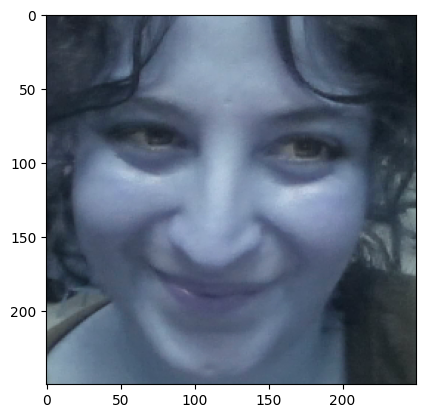

In [13]:
plt.imshow(frame[120:120+250,200:200+250, :])

3. Load and Preprocess Images


3.1 Get Image Directories

In [13]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'\*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH+'\*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH+'\*.jpg').take(300)

In [14]:
dir_test = anchor.as_numpy_iterator()

In [15]:
print(dir_test.next())

b'data\\anchor\\d5477e8d-b38c-11f1-a532-cc47401e05e1.jpg'


3.2 Preprocessing - Scale and Resize

In [16]:
def preprocess(file_path):
    
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load in the image 
    img = tf.io.decode_jpeg(byte_img)
    
    # Preprocessing steps - resizing the image to be 100x100x3
    img = tf.image.resize(img, (100,100))
    # Scale image to be between 0 and 1 
    img = img / 255.0

    # Return image
    return img

In [17]:
img = preprocess('data\\anchor\\fd3bca81-b38c-11f1-a775-cc47401e05e1.jpg')

In [18]:
img.numpy().max()

0.77156866

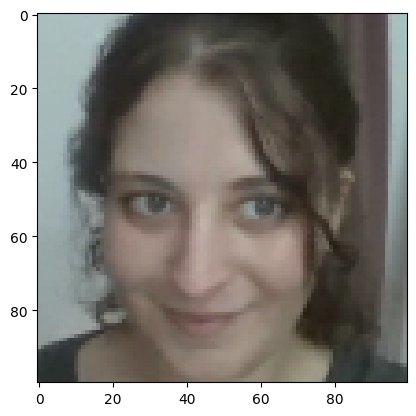

In [22]:
plt.imshow(img)

3.3 Create Labelled Dataset

In [96]:
# (anchor, positive) => 1,1,1,1,1
# (anchor, negative) => 0,0,0,0,0

In [24]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [25]:
samples = data.as_numpy_iterator()

In [26]:
example=samples.next()

In [27]:
example

(b'data\\anchor\\92e0afff-b38c-11f1-9684-cc47401e05e1.jpg',
 b'data\\positive\\cb7172f0-b38d-11f1-91b5-cc47401e05e1.jpg',
 1.0)

3.4 Build Train and Test Partition

In [28]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [56]:
res=preprocess_twin(*example)

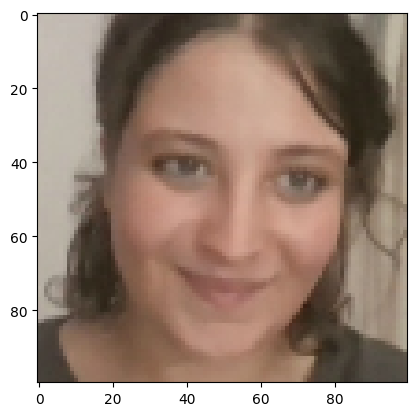

In [57]:
plt.imshow(res[1])

In [58]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [59]:
# Training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [60]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

4. Model Engineering

4.1 Build Embedding Layer

In [61]:
inp = Input(shape=(100,100,3), name='input_image')

In [62]:
c1 = Conv2D(64, (10,10), activation='relu')(inp)

In [63]:
m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

In [64]:
c2 = Conv2D(128, (7,7), activation='relu')(m1)
m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

In [65]:
c3 = Conv2D(128, (4,4), activation='relu')(m2)
m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

In [66]:
c4 = Conv2D(256, (4,4), activation='relu')(m3)
f1 = Flatten()(c4)
d1 = Dense(4096, activation='sigmoid')(f1)

In [67]:
mod = Model(inputs=[inp], outputs=[d1], name='embedding')

In [68]:
mod.summary()

Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 9, 9, 128)         0 

In [69]:
def make_embedding(): 
    inp = Input(shape=(100,100,3), name='input_image')
    
    # First block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # Second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # Third block 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)
    
    # Final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [70]:
embedding = make_embedding()

In [71]:
embedding.summary()

Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 9, 9, 128)         0 

4.2 Build Distance Layer

In [72]:
# Siamese L1 Distance class
class L1Dist(Layer):
    
    # Init method - inheritance
    def __init__(self, **kwargs):
        super().__init__()
       
    # Magic happens here - similarity calculation
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [73]:
l1 = L1Dist()

In [74]:
l1

4.3 Make Siamese Model

In [75]:
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

In [76]:
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [77]:
siamese_layer = L1Dist()

In [78]:
distances = siamese_layer(inp_embedding, val_embedding)

In [79]:
classifier = Dense(1, activation='sigmoid')(distances)

In [80]:
classifier

<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'dense_2')>

In [81]:
siamese_network = Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [82]:
siamese_network.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_1 (L1Dist)              (None, 4096)         0           embedding[0][0]     

In [83]:
def make_siamese_model(): 
    
    # Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))
    
    # Validation image in the network 
    validation_image = Input(name='validation_img', shape=(100,100,3))
    
    # Combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    
    # Classification layer 
    classifier = Dense(1, activation='sigmoid')(distances)
    
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [84]:
siamese_model = make_siamese_model()

In [85]:
siamese_model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
distance (L1Dist)               (None, 4096)         0           embedding[2][0]     

5. Training

5.1 Setup Loss and Optimizer

In [86]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [87]:
opt = tf.keras.optimizers.Adam(1e-4) # 0.0001

In [88]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

5.3 Build Train Step Function

In [89]:
test_batch = train_data.as_numpy_iterator()

In [90]:
batch_1 = test_batch.next()

In [91]:
X = batch_1[:2]

In [92]:
y = batch_1[2]

In [93]:
y

array([0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0.],
      dtype=float32)

In [94]:
@tf.function
def train_step(batch):
    
    # Record all of our operations 
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_model(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)
        
    # Calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    # Calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
        
    # Return loss
    return loss

5.4 Build Training Loop

In [95]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

In [96]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Creating a metric object 
        r = Recall()
        p = Precision()
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            loss = train_step(batch)
            yhat = siamese_model.predict(batch[:2])
            r.update_state(batch[2], yhat)
            p.update_state(batch[2], yhat) 
            progbar.update(idx+1)
        print(loss.numpy(), r.result().numpy(), p.result().numpy())
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

5.5 Train the model

In [97]:
EPOCHS = 50

In [98]:
train(train_data, EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
27/27 [==============================] - 500s 18s/step
0.18446256 0.45544556 1.0

 Epoch 2/50
27/27 [==============================] - 622s 23s/step
0.020126836 0.9675926 0.9858491

 Epoch 3/50
27/27 [==============================] - 735s 27s/step
0.00033661322 0.9858491 0.9905213

 Epoch 4/50
27/27 [==============================] - 648s 24s/step
0.0057576154 0.99509805 0.9902439

 Epoch 5/50
27/27 [==============================] - 586s 22s/step
0.0010337431 1.0 1.0

 Epoch 6/50
27/27 [==============================] - 511s 19s/step
0.0031066418 0.9953052 1.0

 Epoch 7/50
27/27 [==============================] - 559s 20s/step
0.025710758 1.0 1.0

 Epoch 8/50
27/27 [==============================] - 533s 20s/step
0.00023282628 1.0 1.0

 Epoch 9/50
27/27 [==============================] - 486s 18s/step
2.4781319e-05 1.0 

6. Evaluate Model

6.1 Import Metrics

In [99]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

6.2 Make Predictions

In [100]:
# Get a batch of test data
test_input, test_val, y_true = test_data.as_numpy_iterator().next()
y_hat = siamese_model.predict([test_input, test_val])

In [104]:
y_hat = siamese_model.predict([test_input, test_val])

In [122]:
# Post processing the results 
[1 if prediction > 0.5 else 0 for prediction in y_hat ]

[1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0]

In [123]:
y_true

array([1., 1., 0., 0.], dtype=float32)

6.3 Calculate Metrics

In [107]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

1.0

In [108]:
r = Recall()
p = Precision()

for test_input, test_val, y_true in test_data.as_numpy_iterator():
    yhat = siamese_model.predict([test_input, test_val])
    r.update_state(y_true, yhat)
    p.update_state(y_true,yhat) 

print(r.result().numpy(), p.result().numpy())

1.0 1.0


6.4 Viz Results

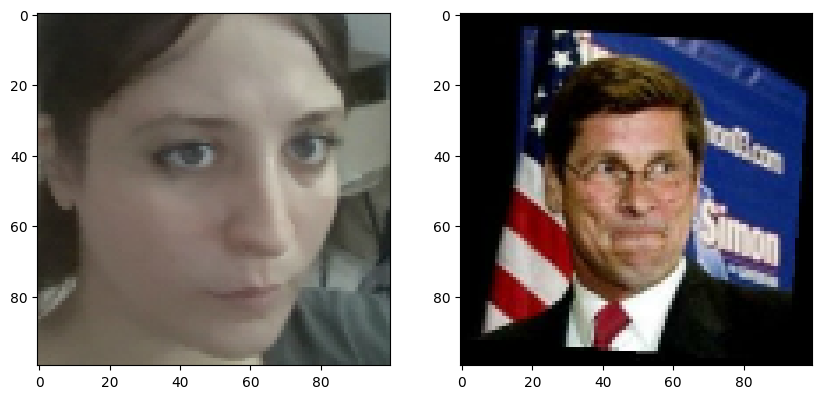

In [124]:
# Set plot size 
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[2])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[2])

# Renders cleanly
plt.show()

7. Save Model

In [125]:
# Save weights
siamese_model.save('siamesemodelv2.h5')

In [126]:
# Reload model 
siamese_model = tf.keras.models.load_model('siamesemodelv2.h5', 
                                   custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

In [127]:
# Make predictions with reloaded model
siamese_model.predict([test_input, test_val])

array([[1.0000000e+00],
       [9.9999720e-01],
       [3.8111967e-09],
       [1.0208355e-09]], dtype=float32)

In [128]:
# View model summary
siamese_model.summary()


Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_3 (L1Dist)              (None, 4096)         0           embedding[0][0]     

8. Real Time Test

8.1 Verification Function

In [143]:
def verify(model, detection_threshold, verification_threshold):
    # Build results array
    results = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image))
        
        # Make Predictions 
        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        results.append(result)
    
    # Detection Threshold: Metric above which a prediciton is considered positive 
    detection = np.sum(np.array(results) > detection_threshold)
    
    # Verification Threshold: Proportion of positive predictions / total positive samples 
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images'))) 
    verified = verification > verification_threshold
    
    return results, verified

8.2 OpenCV Real Time Verification

In [146]:
import cv2
import os

# Connect to camera index 0 with DirectShow on Windows
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Error: Could not access webcam at index 0.")
else:
    print("Webcam active! Press 'v' to verify, 'q' to quit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break
        
    # Crop to 250x250px for Siamese verification
    cropped_frame = frame[120:120+250, 200:200+250, :]
    
    # Show the cropped verification window
    cv2.imshow('Verification', cropped_frame)
    
    # Capture keypress once
    key = cv2.waitKey(1) & 0xFF
    
    # Verification trigger - press 'v'
    if key == ord('v'):
        save_path = os.path.join('application_data', 'input_image', 'input_image.jpg')
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, cropped_frame)
        
        # Run verification
        results, verified = verify(siamese_model, 0.9, 0.7)
        print("Verification Result:", verified)
    
    # Quit trigger - press 'q'
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Webcam active! Press 'v' to verify, 'q' to quit.
Verification Result: False
